In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../EDA/Reviews.csv')

# Convert time
df['Time'] = pd.to_datetime(df['Time'], unit='s')
df['Year'] = df['Time'].dt.year
df['Month'] = df['Time'].dt.month

# Clean
df = df.drop_duplicates()
df = df.dropna(subset=['Summary', 'Text'])
df = df[df['HelpfulnessDenominator'] > 0]
df['HelpfulnessRatio'] = df['HelpfulnessNumerator'] / df['HelpfulnessDenominator']
df['ReviewLength'] = df['Text'].apply(len)

print("Ready:", df.shape)

Ready: (298376, 14)


In [2]:
# Set global style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

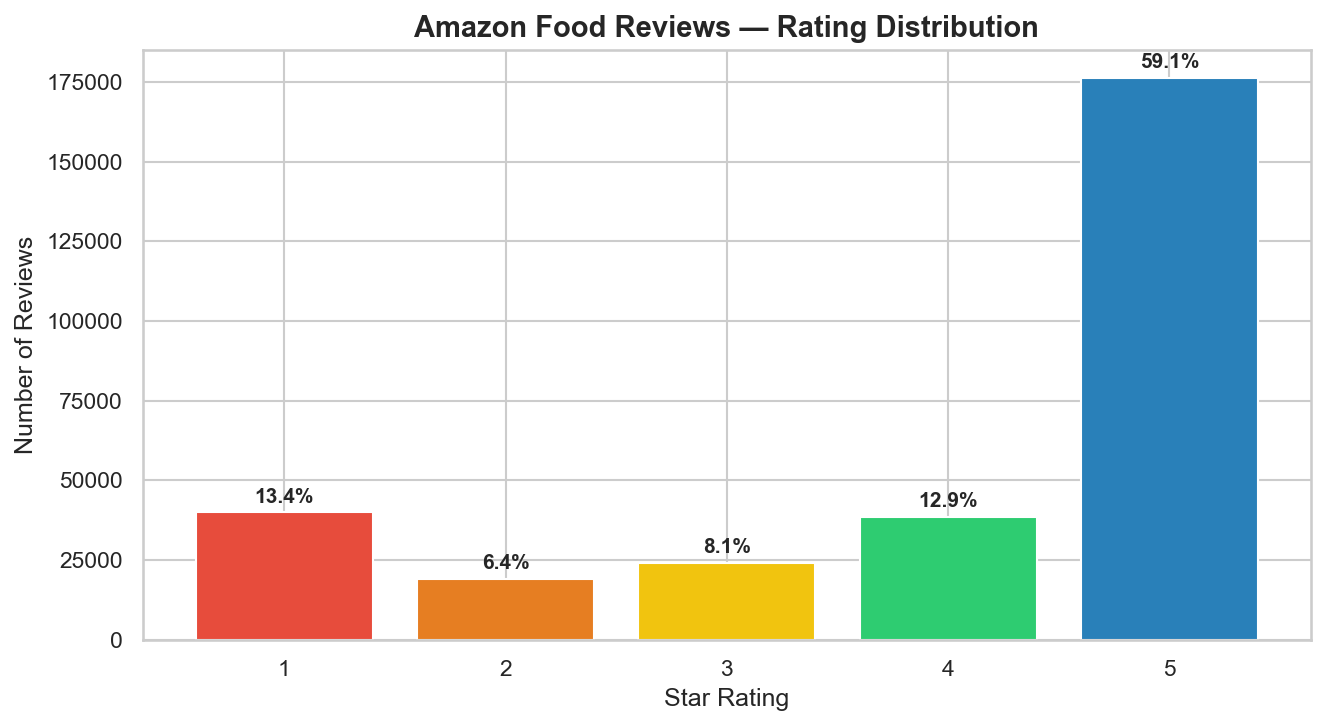

In [4]:
# Chart 1 — Score Distribution with percentages
fig, ax = plt.subplots(figsize=(9, 5))
score_counts = df['Score'].value_counts().sort_index()
bars = ax.bar(score_counts.index, score_counts.values, 
              color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#2980b9'])

for bar, val in zip(bars, score_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f'{val/len(df)*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Amazon Food Reviews — Rating Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
plt.tight_layout()
plt.savefig('visuals/01_rating_distribution.png', dpi=150)
plt.show()

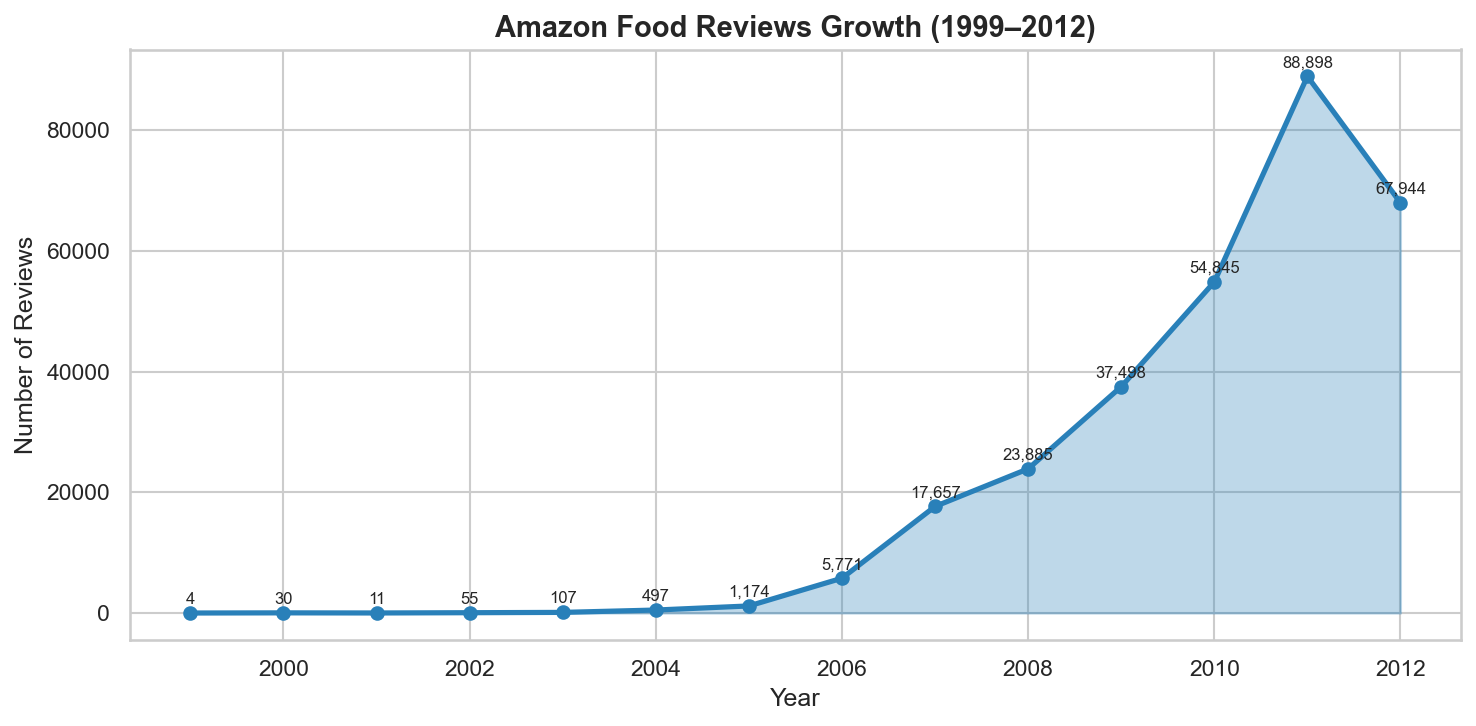

In [5]:
# Chart 2 — Reviews growth over time
yearly = df.groupby('Year').size().reset_index(name='ReviewCount')

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(yearly['Year'], yearly['ReviewCount'], alpha=0.3, color='#2980b9')
ax.plot(yearly['Year'], yearly['ReviewCount'], color='#2980b9', 
        linewidth=2.5, marker='o', markersize=6)

for _, row in yearly.iterrows():
    ax.text(row['Year'], row['ReviewCount'] + 1500, 
            f"{int(row['ReviewCount']):,}", ha='center', fontsize=8)

ax.set_title('Amazon Food Reviews Growth (1999–2012)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
plt.tight_layout()
plt.savefig('visuals/02_reviews_growth.png', dpi=150)
plt.show()

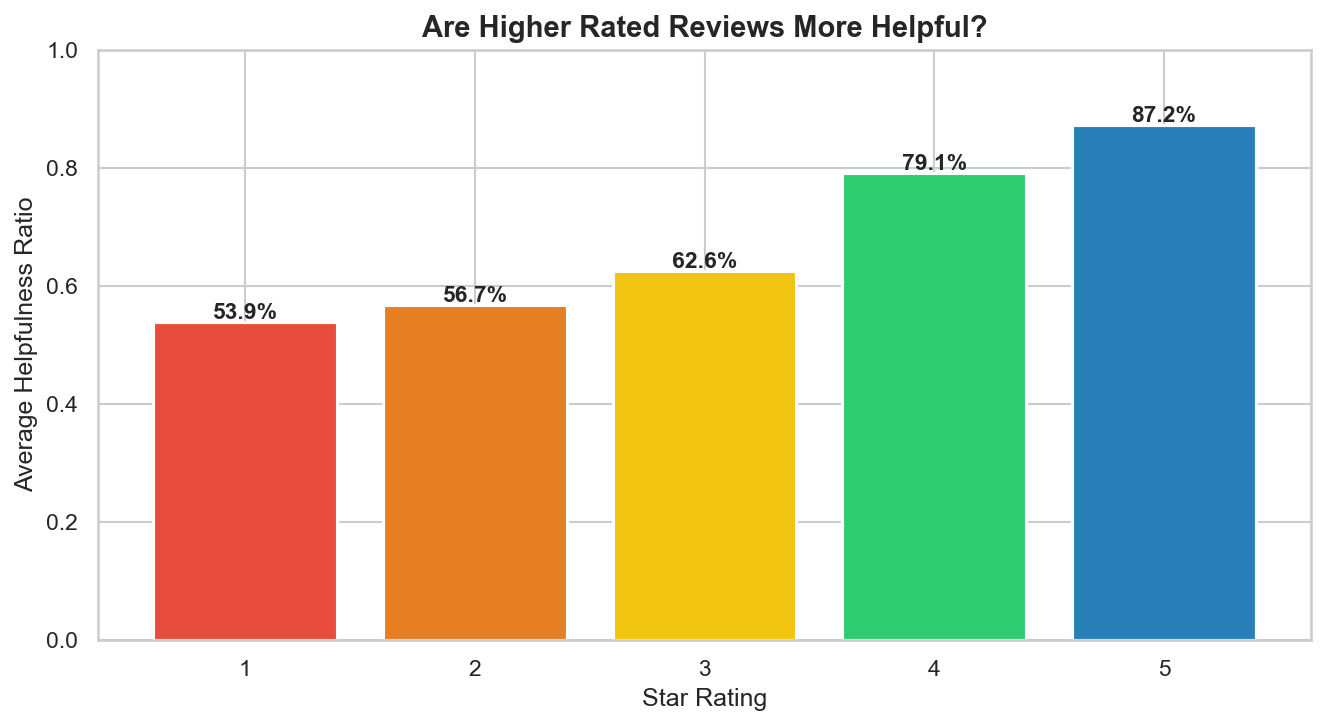

In [6]:
# Chart 3 — Helpfulness ratio by score
helpful = df.groupby('Score')['HelpfulnessRatio'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#2980b9']
bars = ax.bar(helpful['Score'], helpful['HelpfulnessRatio'], color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, helpful['HelpfulnessRatio']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Are Higher Rated Reviews More Helpful?', fontsize=14, fontweight='bold')
ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('Average Helpfulness Ratio', fontsize=12)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('visuals/03_helpfulness_by_rating.png', dpi=150)
plt.show()

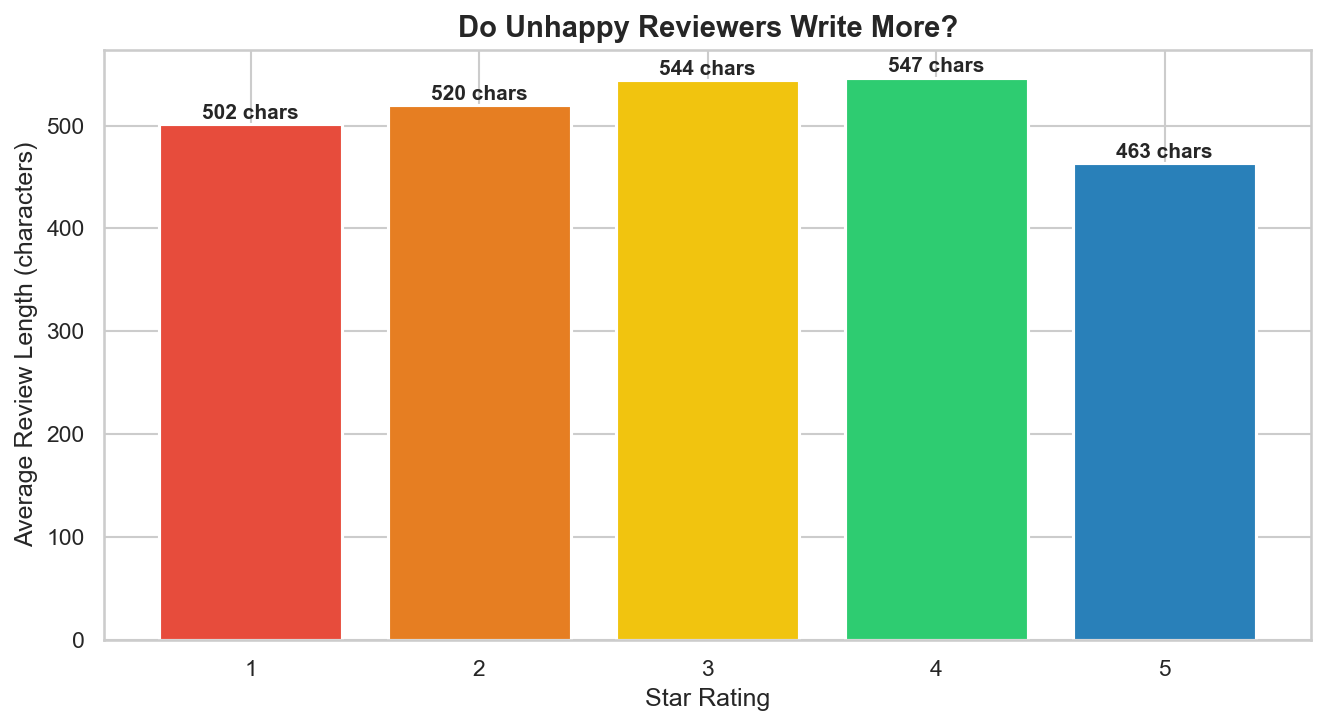

In [7]:
# Chart 4 — Review length by score
length_data = df.groupby('Score')['ReviewLength'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#2980b9']
bars = ax.bar(length_data['Score'], length_data['ReviewLength'], 
              color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, length_data['ReviewLength']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:.0f} chars', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Do Unhappy Reviewers Write More?', fontsize=14, fontweight='bold')
ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('Average Review Length (characters)', fontsize=12)
plt.tight_layout()
plt.savefig('visuals/04_review_length_by_score.png', dpi=150)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_3632\1204534181.py:19: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_3632\1204534181.py:20: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.savefig('visuals/05_top_products.png', dpi=150)
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


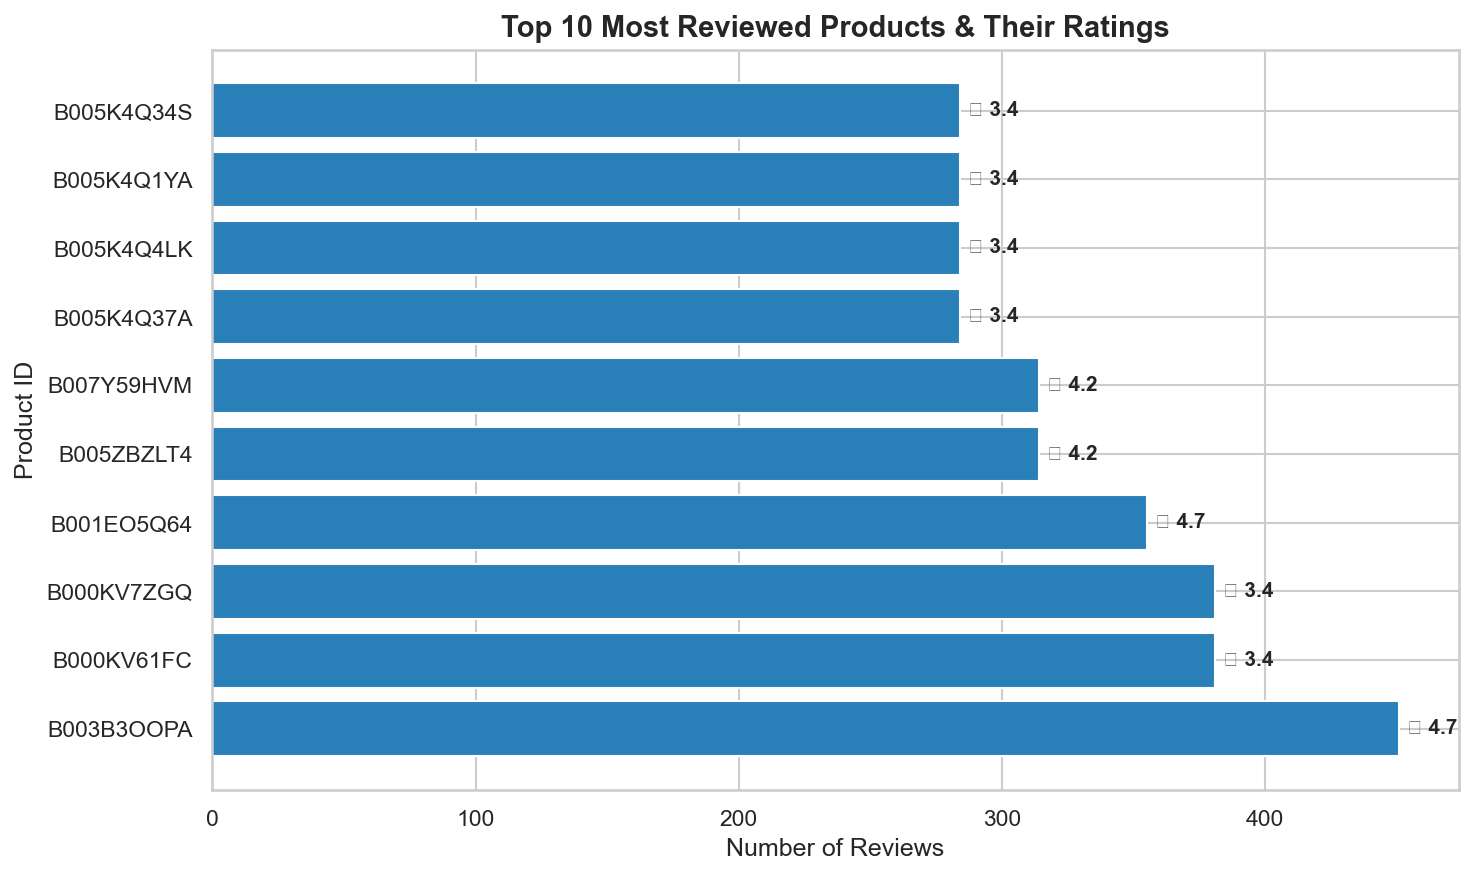

In [8]:
# Chart 5 — Top 10 most reviewed products
top_products = df['ProductId'].value_counts().head(10).reset_index()
top_products.columns = ['ProductId', 'ReviewCount']
top_scores = df.groupby('ProductId')['Score'].mean().reset_index()
top_products = top_products.merge(top_scores, on='ProductId')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_products['ProductId'], top_products['ReviewCount'],
               color='#2980b9', edgecolor='white')

for bar, score in zip(bars, top_products['Score']):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'⭐ {score:.1f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Most Reviewed Products & Their Ratings', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Reviews', fontsize=12)
ax.set_ylabel('Product ID', fontsize=12)
plt.tight_layout()
plt.savefig('visuals/05_top_products.png', dpi=150)
plt.show()

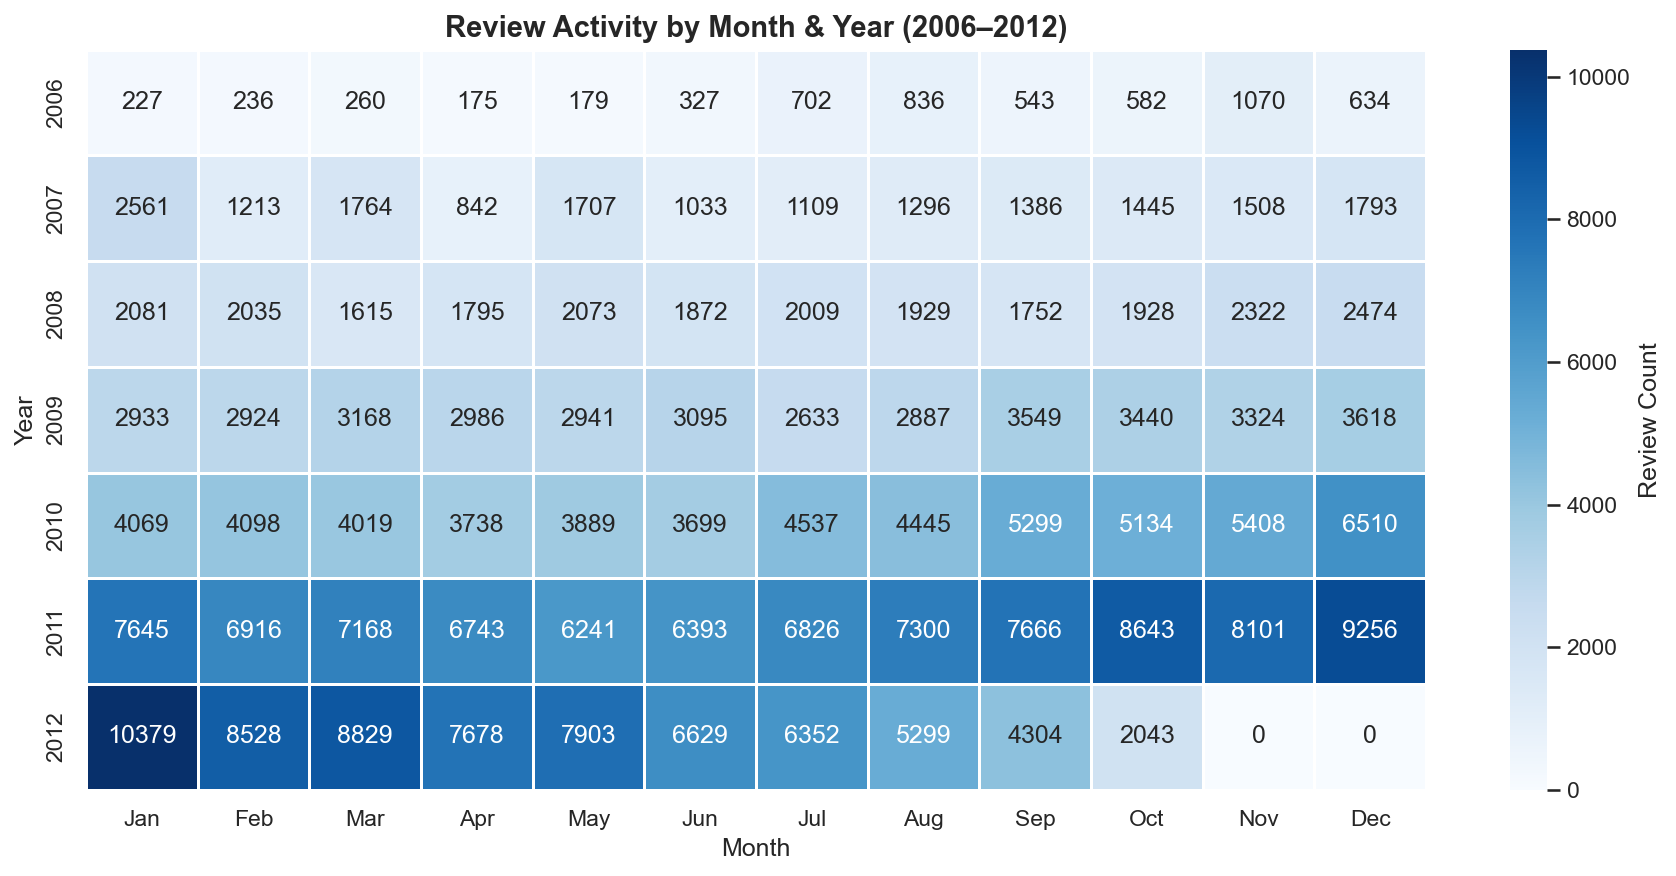

In [9]:
# Chart 6 — Heatmap of reviews by year and month
df['Month'] = df['Time'].dt.month
heatmap_data = df.groupby(['Year', 'Month']).size().unstack(fill_value=0)

# Filter from 2006 onwards - more interesting data
heatmap_data = heatmap_data[heatmap_data.index >= 2006]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='Blues', linewidths=0.5, 
            annot=True, fmt='d', ax=ax, cbar_kws={'label': 'Review Count'})

ax.set_title('Review Activity by Month & Year (2006–2012)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.savefig('visuals/06_heatmap_reviews.png', dpi=150)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_3632\1360642704.py:54: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_3632\1360642704.py:55: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig('visuals/07_dashboard.png', dpi=150, bbox_inches='tight')
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


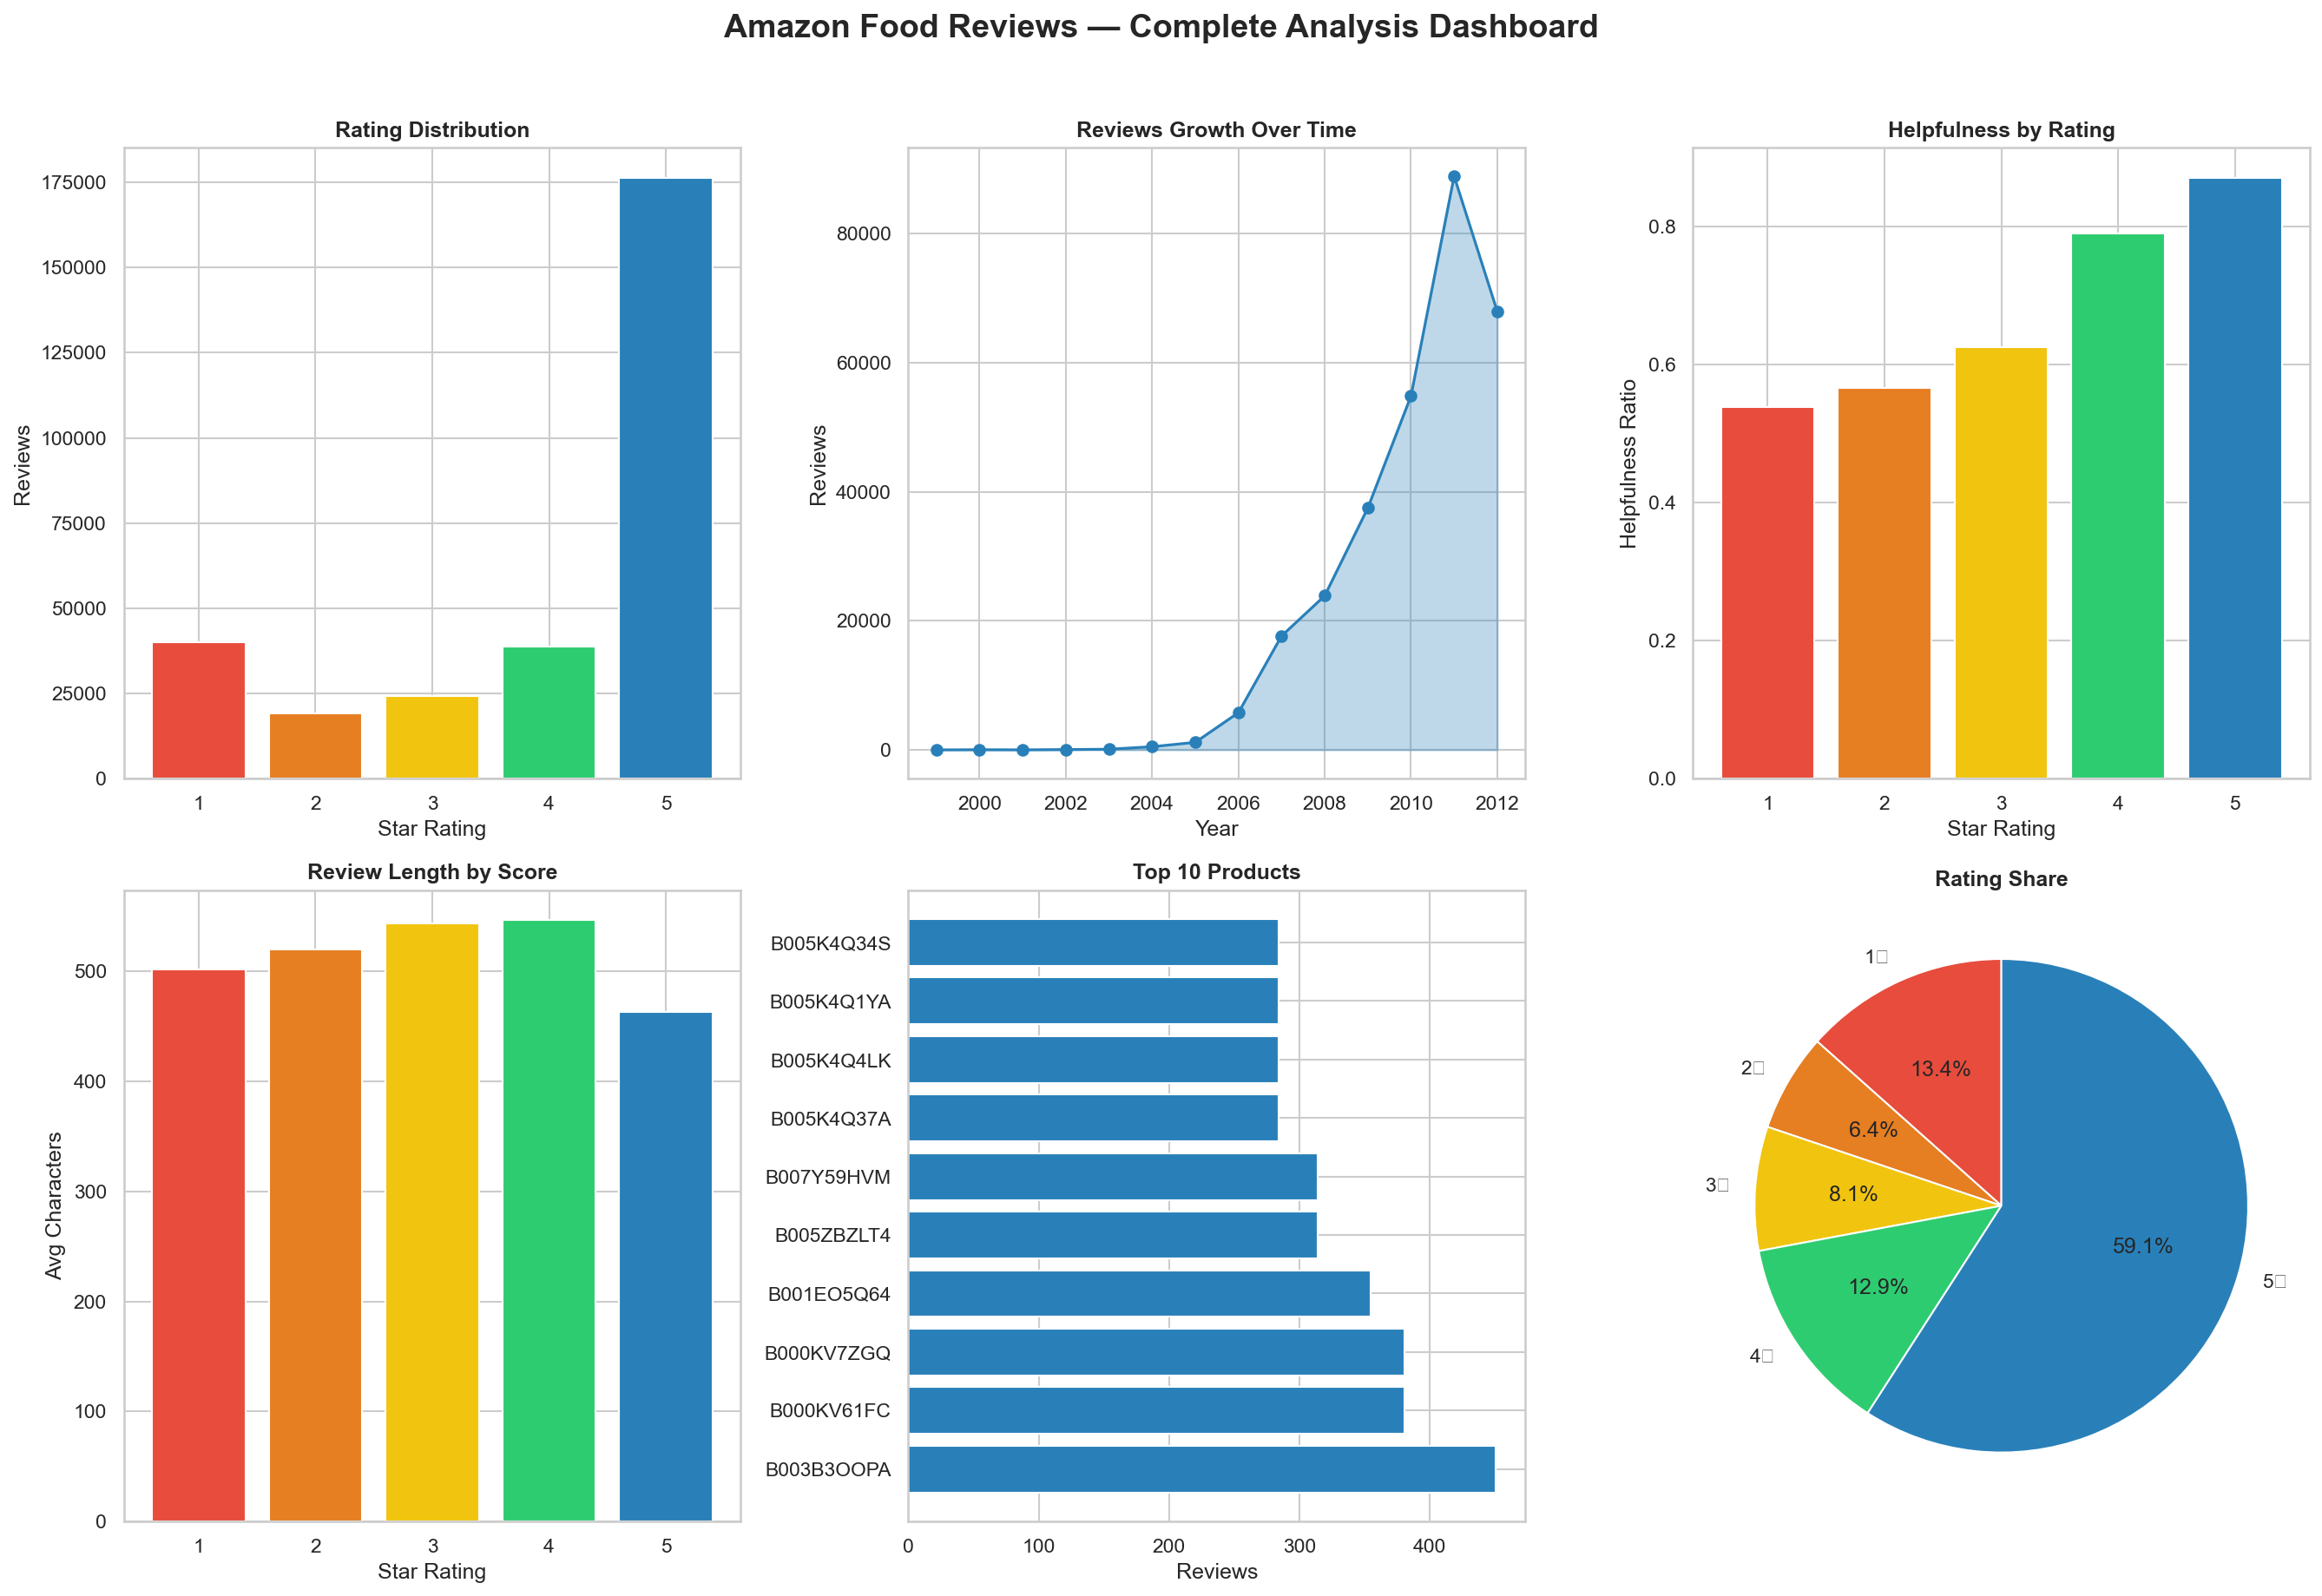

In [10]:
# Dashboard — All insights in one figure
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Amazon Food Reviews — Complete Analysis Dashboard', 
             fontsize=18, fontweight='bold', y=1.02)

# Chart 1 — Rating Distribution
ax1 = fig.add_subplot(2, 3, 1)
score_counts = df['Score'].value_counts().sort_index()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#2980b9']
ax1.bar(score_counts.index, score_counts.values, color=colors)
ax1.set_title('Rating Distribution', fontweight='bold')
ax1.set_xlabel('Star Rating')
ax1.set_ylabel('Reviews')

# Chart 2 — Growth over time
ax2 = fig.add_subplot(2, 3, 2)
yearly = df.groupby('Year').size().reset_index(name='ReviewCount')
ax2.fill_between(yearly['Year'], yearly['ReviewCount'], alpha=0.3, color='#2980b9')
ax2.plot(yearly['Year'], yearly['ReviewCount'], color='#2980b9', marker='o')
ax2.set_title('Reviews Growth Over Time', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Reviews')

# Chart 3 — Helpfulness
ax3 = fig.add_subplot(2, 3, 3)
helpful = df.groupby('Score')['HelpfulnessRatio'].mean().reset_index()
ax3.bar(helpful['Score'], helpful['HelpfulnessRatio'], color=colors)
ax3.set_title('Helpfulness by Rating', fontweight='bold')
ax3.set_xlabel('Star Rating')
ax3.set_ylabel('Helpfulness Ratio')

# Chart 4 — Review Length
ax4 = fig.add_subplot(2, 3, 4)
length_data = df.groupby('Score')['ReviewLength'].mean().reset_index()
ax4.bar(length_data['Score'], length_data['ReviewLength'], color=colors)
ax4.set_title('Review Length by Score', fontweight='bold')
ax4.set_xlabel('Star Rating')
ax4.set_ylabel('Avg Characters')

# Chart 5 — Top Products
ax5 = fig.add_subplot(2, 3, 5)
top_products = df['ProductId'].value_counts().head(10).reset_index()
top_products.columns = ['ProductId', 'ReviewCount']
ax5.barh(top_products['ProductId'], top_products['ReviewCount'], color='#2980b9')
ax5.set_title('Top 10 Products', fontweight='bold')
ax5.set_xlabel('Reviews')

# Chart 6 — Pie chart of ratings
ax6 = fig.add_subplot(2, 3, 6)
ax6.pie(score_counts.values, labels=[f'{i}★' for i in score_counts.index],
        colors=colors, autopct='%1.1f%%', startangle=90)
ax6.set_title('Rating Share', fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/07_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()